# 3.3.1 向量场相轨迹与时间

## 学习目标与先修知识

能从状态（state）点计算运动方向和速度，将时间曲线与相轨迹（phase trajectory）对应，并说明归一化箭头和几何路径各自省略的信息。

先修：状态空间（state space）、模态（mode）解析轨迹（trajectory）、向量（vector）长度。 [复习上一节](../02-线性状态空间与动态模态/03-复数模态与阻尼旋转.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一条状态路径可以慢慢走，也可以快速走。若两张相图（phase portrait）看上去完全相同，我们能否断言两套系统的动态相同？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
M=np.array([[-1,0],[0,-2]])
for point in [[1,1],[0,0],[-1,1]]:
    velocity=M@point
    print('位置',point,'变化率',velocity,'加倍后',2*velocity)

位置 [1, 1] 变化率 [-1 -2] 加倍后 [-2 -4]
位置 [0, 0] 变化率 [0 0] 加倍后 [0 0]
位置 [-1, 1] 变化率 [ 1 -2] 加倍后 [ 2 -4]


## 模型假设

使用人工二维偏差模型（model），不额外假定为所追踪物质总量（tracked amount）。主例 M=diag(−1,−2)/T、x0=[1,1] U，比较 M 与 2M；两分量同单位。方向场将非零箭头缩成等长，只显示方向；速度另用数值和等时间点表达。

## 数学解释与推导

自治系统 $\dot x=f(x)$ 在每个状态点赋予一个变化率向量，这组成向量场（vector field）。取很短 h，有 $x(t+h)\approx x(t)+h f(x(t))$，所以向量指向下一瞬间。二维状态构成相平面（phase plane）；把不同时刻的 $(x_1(t),x_2(t))$ 连起来是相轨迹，多初值（initial condition）轨迹与方向场一起构成相图。

平衡（equilibrium）满足整个 f(x*)=0；某个分量为零，只表示该坐标瞬时不动。主例 $x_1=e^{-t}$、$x_2=e^{-2t}$。消去时间得 $x_2=x_1^2$，但几何关系没有告诉你多久到达某点。欧几里得速度是 $\|f(x)\|_2$，单位 U/T。

将整个向量场乘正倍率 s。若 x(t) 是原解，令 z(t)=x(st)，链式法则（chain rule）给 $\dot z=s f(z)$。因此同初值的轨迹路径和方向不变，时钟加快 s 倍；t 时刻对应原来的 st。s<0 会反转方向，s=0 停止，本节比较只允许 s>0。

箭头等长处理是 $f/\|f\|$，不能再用长度比较速度。平衡点的零向量不可除以零，应单独标记。等时间标记若在平面中越近，只能在坐标尺度一致、相邻时段足够短时提示更慢；精确速度仍由原 f 计算。

相图也不应随意拉伸：相同单位的两个坐标采用等比例显示，才能直观比较长度和角度；不同物理单位则应解释坐标缩放。几何信息和时间信息是互补视角。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def scaled_field(matrix, points, multiplier):
    import math
    original = [[sum(row[j]*point[j] for j in range(2)) for row in matrix] for point in points]
    scaled = [[multiplier*x for x in row] for row in original]
    speeds = [math.sqrt(sum(x*x for x in row)) for row in scaled]
    return original, scaled, speeds

## 对照实验

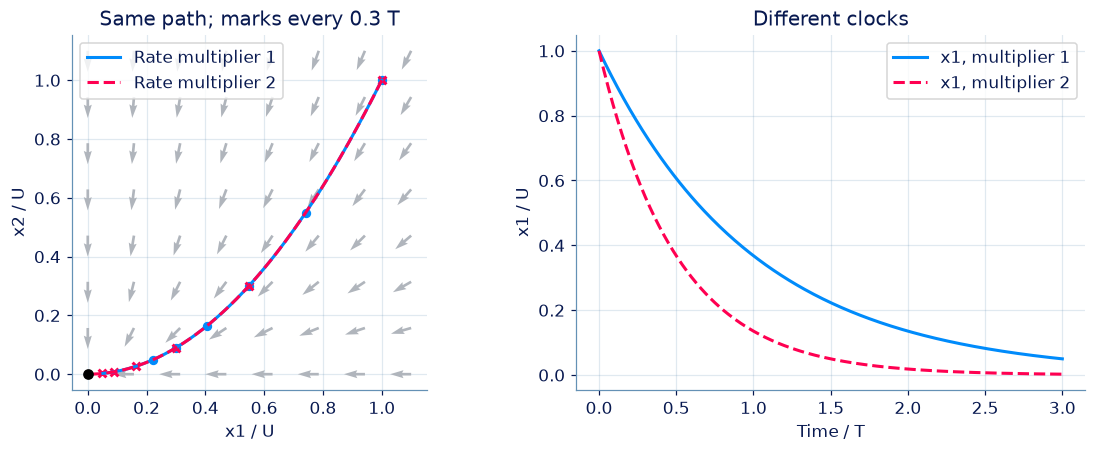

| 位置 | 原速度 / (U/T) | 加倍速度 / (U/T) |
| --- | --- | --- |
| [1, 1] | 2.23607 | 4.47214 |
| [0.5, 0.25] | 0.707107 | 1.41421 |
| [0, 0] | 0 | 0 |

In [4]:
times=np.linspace(0,3,301)
grid=np.linspace(0,1.1,8);X,Y=np.meshgrid(grid,grid);U,V=-X,-2*Y
speed=np.hypot(U,V);safe=np.where(speed>0,speed,1)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].quiver(X,Y,U/safe,V/safe,angles='xy',scale_units='xy',scale=14,color='#b0b5bc')
for s,color,style in [(1,BLUE,'-'),(2,PINK,'--')]:
    x=np.exp(-s*times);y=np.exp(-2*s*times)
    axes[0].plot(x,y,style,color=color,label=f'Rate multiplier {s}')
    marks=np.arange(0,1.51,.3)
    axes[0].scatter(np.exp(-s*marks),np.exp(-2*s*marks),marker='o' if s==1 else 'x',color=color,s=26)
    axes[1].plot(times,x,style,color=color,label=f'x1, multiplier {s}')
axes[0].plot(0,0,'ko');axes[0].set(xlabel='x1 / U',ylabel='x2 / U',title='Same path; marks every 0.3 T');axes[0].set_aspect('equal');axes[0].legend()
axes[1].set(xlabel='Time / T',ylabel='x1 / U',title='Different clocks');axes[1].legend();plt.show()
display(Markdown(show_table(['位置','原速度 / (U/T)','加倍速度 / (U/T)'],[(str(p),np.linalg.norm(M@p),np.linalg.norm(2*M@p)) for p in [[1,1],[.5,.25],[0,0]]])))

## 结果解释

左图两条几何路径重合，等时间标记却处在不同位置；右图显示加倍系统更早靠近零。灰箭头一律等长，不编码速度。

### 独立核对

图形重合不是核验充分条件；把缩放轨迹与原模型相应时刻的解析状态直接比较。

In [5]:
points=[[1,1],[.5,.25],[0,0]]
original,scaled,speeds=scaled_field(M.tolist(),points,2)
np.testing.assert_allclose(scaled,2*np.array(original))
np.testing.assert_allclose(speeds,2*np.linalg.norm(original,axis=1))
for t in [.2,1]:
    fast=np.array([math.exp(-2*t),math.exp(-4*t)])
    slow_later=np.array([math.exp(-(2*t)),math.exp(-2*(2*t))])
    np.testing.assert_allclose(fast,slow_later)
assert speeds[-1]==0
print('方向、速度、时间重参数化与零向量处理一致。')

方向、速度、时间重参数化与零向量处理一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-03-耦合、相平面与平衡/explore/)：改变一个条件，观察时间曲线与状态空间中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：同一条路径可以走得更快

无输入（input）二维系统 x′=Mx。对指定状态（state）点计算变化率，再把整个 M 乘正数 multiplier。返回原向量场（vector field）、缩放后的向量场，以及缩放后每点的欧几里得速度。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    points: list[list[float]],
    multiplier: float,
) -> tuple[list[list[float]], list[list[float]], list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 2×2 系统矩阵（matrix）。 | 1/T |
| `points` | `list[list[float]]` | 各行是一个状态点 [x1,x2]，分量使用同一单位。 | U |
| `multiplier` | `float` | 全部变化率的共同倍率。 | 1 |

**返回值**

按以下顺序返回元组：(original, scaled, speeds)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `original` | `list[list[float]]` | 原模型（model）各点的变化率。 | U/T |
| `scaled` | `list[list[float]]` | 乘倍率后的变化率。 | U/T |
| `speeds` | `list[float]` | 缩放变化率的长度，顺序与 points 相同。 | U/T |

**计算规则**

original[i]=M×points[i]；scaled=multiplier×original；speeds[i]=sqrt(scaled[i][0]²+scaled[i][1]²)。

**约束与边界**

- 所有数值有限；不修改输入列表。
- matrix 各元素绝对值≤2；points 长度 1—30，各分量绝对值≤10；0.1≤multiplier≤5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 2×2 系统矩阵（matrix）。 | [[-1, 0], [0, -2]] | 1/T |
| points | 各行是一个状态点 [x1,x2]，分量使用同一单位。 | [[1, 1], [0, 0]] | U |
| multiplier | 全部变化率的共同倍率。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[-1, 0], [0, -2]]
points = [[1, 1], [0, 0]]
multiplier = 2

result = solve(matrix, points, multiplier)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| original | 原模型（model）各点的变化率。 | [[-1, -2], [0, 0]] | U/T |
| scaled | 乘倍率后的变化率。 | [[-2, -4], [0, 0]] | U/T |
| speeds | 缩放变化率的长度，顺序与 points 相同。 | [4.47213595499958, 0.0] | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-1, -2], [0, 0]],
                   [[-2, -4], [0, 0]],
                   [4.47213595499958, 0.0])
```

**样例解释**

在 [1,1] 原方向为 [−1,−2]，加倍后 [−2,−4]，速度为 sqrt(20)；原点速度为零。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同一条路径可以走得更快](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-scaled-field)

### 第 2 题 · 多项选择题：一张相图省略了什么

两条相轨迹（phase trajectory）几何路径完全重合，箭头同向，但一条模型（model）的变化率是另一条的两倍。哪些成立？

- **A.** 同一路径不保证同一时刻位于同一点。
- **B.** 时间曲线可以区分二者。
- **C.** 几何路径已证明速度相同。
- **D.** 相图（phase portrait）加等时间标记能帮助比较速度。

[作答：一张相图省略了什么](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-phase-time)

### 第 3 题 · 单项选择题：等长箭头可以比较速度吗

方向场把所有非零箭头都归一化为相同长度。下列哪项解释正确？

- **A.** 只说明方向，速度需看数值或等时间标记。
- **B.** 所有状态（state）点速度都一样。
- **C.** 平衡（equilibrium）点必须画一个任意方向的箭头。
- **D.** 箭头越密表示运动越快。

[作答：等长箭头可以比较速度吗](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-normalized-arrows)

### 第 4 题 · 单项选择题：一条分量为零等于平衡吗

某点 x′=[0,2] U/T。对于二维自治系统，这个点是什么情况？

- **A.** 已在平衡（equilibrium），因为第一分量为零。
- **B.** 沿第二坐标正向运动，尚非平衡。
- **C.** 必定沿封闭周期运动。
- **D.** 所有初值（initial condition）都会经过它。

[作答：一条分量为零等于平衡吗](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-equilibrium-direction)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。